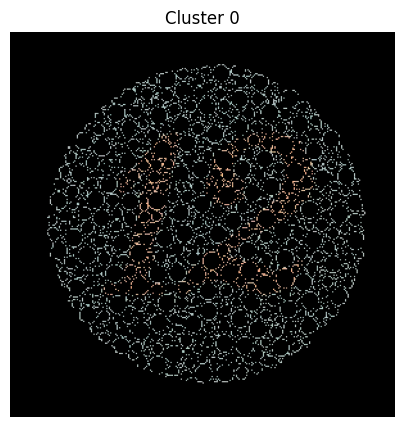

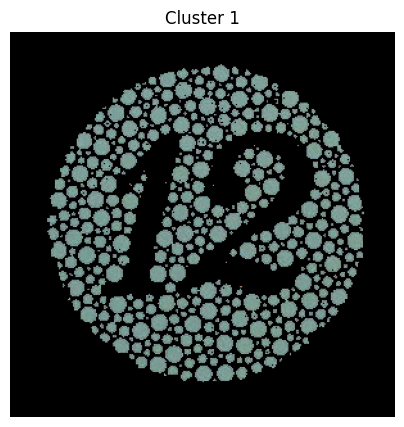

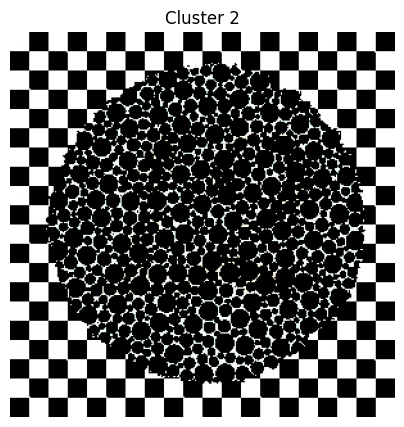

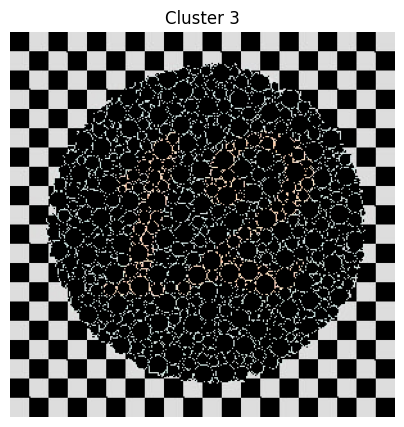

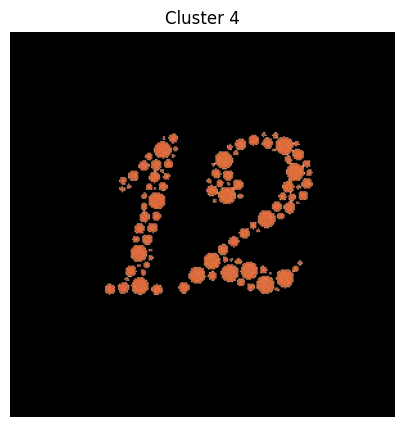

Enter clusters to combine (comma-separated): 4


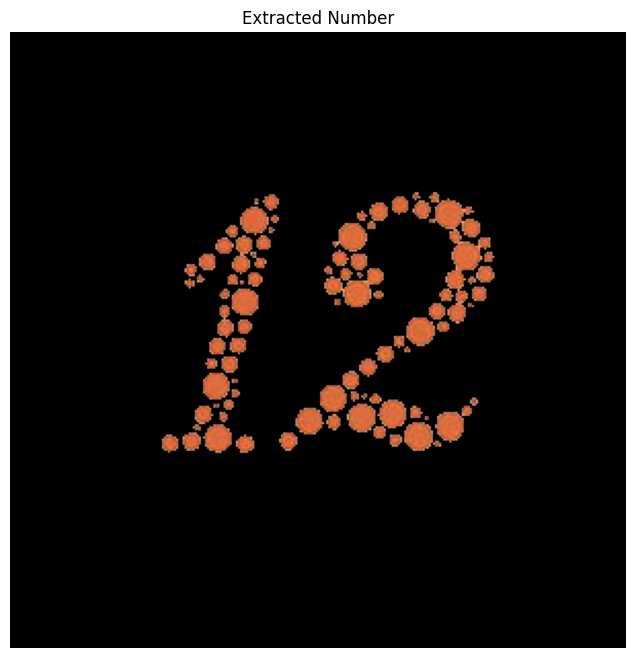

In [17]:
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

class K_Means:
    def __init__(self, k=2, tolerance=0.001, max_iter=500):
        self.k = k
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.centroids = None
        self.labels = None

    def _initialize_centroids(self, data):
        # initialization: random points from dataset
        indices = np.random.choice(data.shape[0], self.k, replace=False)
        return data[indices]

    def _assign_clusters(self, data):
        # Vectorized distance calculation
        distances = np.linalg.norm(data[:, np.newaxis] - self.centroids, axis=2)
        return np.argmin(distances, axis=1)

    def _update_centroids(self, data, labels):
        new_centroids = np.zeros_like(self.centroids)
        for i in range(self.k):
            # Handle empty clusters by keeping previous centroid
            if np.sum(labels == i) > 0:
                new_centroids[i] = np.mean(data[labels == i], axis=0)
            else:
                new_centroids[i] = self.centroids[i]
        return new_centroids

    def fit(self, data):
        self.centroids = self._initialize_centroids(data)

        for _ in range(self.max_iter):
            old_centroids = self.centroids.copy()

            # Assign points to nearest centroid
            self.labels = self._assign_clusters(data)

            # Update centroids
            self.centroids = self._update_centroids(data, self.labels)

            # Check for convergence (global change)
            centroid_shift = np.linalg.norm(old_centroids - self.centroids)
            if centroid_shift < self.tolerance:
                break

        return self.labels, self.centroids

# Image processing pipeline
def process_image(image_path, k=4):
    # Load and prepare image
    image = Image.open(image_path).convert('RGB')
    image = image.resize((300, 300))
    image_np = np.array(image)
    h, w, _ = image_np.shape
    flat_image = image_np.reshape((-1, 3)).astype(np.float32)

    # Apply K-means
    model = K_Means(k=k)
    labels, centers = model.fit(flat_image)
    labels = labels.reshape((h, w))

    # Visualize clusters
    for cluster_num in range(k):
        mask = labels == cluster_num
        output = np.zeros_like(image_np)
        output[mask] = image_np[mask]

        plt.figure(figsize=(5, 5))
        plt.imshow(output)
        plt.title(f'Cluster {cluster_num}')
        plt.axis('off')
        plt.show()

    return labels, image_np

# Example usage
if __name__ == "__main__":
    image_path = '/content/12.jpg'
    k = 5

    labels, image_np = process_image(image_path, k=k)

    # Cluster selection interface
    input_clusters = input("Enter clusters to combine (comma-separated): ")
    number_clusters = list(map(int, input_clusters.split(',')))

    mask = np.isin(labels, number_clusters)
    output = np.zeros_like(image_np)
    output[mask] = image_np[mask]

    plt.figure(figsize=(8, 8))
    plt.imshow(output)
    plt.title("Extracted Number")
    plt.axis('off')
    plt.show()